<a href="https://colab.research.google.com/github/gabrielbarata/MVP-machine-learning/blob/main/MVP_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pathos

In [ ]:
import tensorflow as tf
from keras import layers, models
import numpy as np

# 1. Carregar e preparar o dataset MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_raw = np.concat([x_train,x_test])
y_raw = np.concat([y_train,y_test])


class_names = {int(i):str(i) for i in np.unique(y_raw)}



print(f"x_train: {len(x_raw)} x {x_raw[0].shape}, y_train: {y_raw.shape}")
print(f"Class Names: {class_names}")

x_train: 70000 x (28, 28), y_train: (70000,)
Class Names: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


In [ ]:
class Dataset:
  data_dict = {}
  class_names = {}
  @classmethod
  def create(cls, old:str, new:str, func):
    keys = [k for k in cls.data_dict.keys() if old in k]
    for k in keys:
      cls.data_dict[k.replace(old, new)] = func(cls.data_dict[k])

Dataset.data_dict["x_raw"] = x_raw
Dataset.data_dict["y_raw"] = y_raw
Dataset.class_names = class_names

In [ ]:
Dataset.data_dict.keys()

dict_keys(['x_raw', 'y_raw'])

In [ ]:
import kagglehub
import os

# O erro anterior ocorria porque 'file_path' estava vazio.
# Para datasets de imagens, geralmente baixamos o caminho local primeiro.
path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-30-classes" )
print("Dataset baixado em:", path)



Using Colab cache for faster access to the 'brain-tumor-mri-images-30-classes' dataset.
Dataset baixado em: /kaggle/input/brain-tumor-mri-images-30-classes


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vijaykumar1799/face-mask-detection")
path = f"{path}/Dataset"
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-detection' dataset.
Path to dataset files: /kaggle/input/face-mask-detection/Dataset


In [ ]:
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split
from pathos.multiprocessing import ProcessingPool as Pool

In [ ]:
import gc

# 1. Delete large dataframes, lists, or models

# 2. Force Python to free up unreferenced memory
gc.collect()

20558

In [ ]:


# Função de tarefa sem dependências externas
def process_load_task(args):
    img_path, label = args
    try:
        # Leitura inline (não depende de read_image_helper)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            return img, label
    except:
        pass
    return None

def load_kaggle_brain_data_parallel(base_path):
    categories = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    label_map = {category: i for i, category in enumerate(categories)}

    # Create a reverse map for class names
    class_names_map = {i: category for category, i in label_map.items()}

    print(f"Encontradas {len(categories)} classes. Preparando lista de tarefas...")

    tasks = []
    for category in categories:
        folder_path = os.path.join(base_path, category)
        label = label_map[category]
        for img_name in os.listdir(folder_path):
            tasks.append((os.path.join(folder_path, img_name), label))

    print(f"Carregando {len(tasks)} imagens em paralelo...")
    with Pool() as pool:
        results = pool.map(process_load_task, tasks)

    valid_results = [r for r in results if r is not None]
    x = [r[0] for r in valid_results]
    y = np.array([r[1] for r in valid_results])

    return x, y, class_names_map


x_raw, y_raw, class_names = load_kaggle_brain_data_parallel(path)
print(f"x_train: {len(x_raw)} x {x_raw[0].shape}, y_train: {y_raw.shape}")
print(f"Class Names: {class_names}")

Encontradas 30 classes. Preparando lista de tarefas...
Carregando 11300 imagens em paralelo...
x_train: 11300 x (512, 512), y_train: (11300,)
Class Names: {0: 'Astrocytoma T1', 1: 'Astrocytoma T1C+', 2: 'Astrocytoma T2', 3: 'Ependymoma T1', 4: 'Ependymoma T1C+', 5: 'Ependymoma T2', 6: 'Glioma T1', 7: 'Glioma T1C+', 8: 'Glioma T2', 9: 'Hemangiopericytoma T1', 10: 'Hemangiopericytoma T1C+', 11: 'Hemangiopericytoma T2', 12: 'Meningioma T1', 13: 'Meningioma T1C+', 14: 'Meningioma T2', 15: 'Neurocytoma T1', 16: 'Neurocytoma T1C+', 17: 'Neurocytoma T2', 18: 'Normal T1', 19: 'Normal T1C+', 20: 'Normal T2', 21: 'Oligodendroglioma T1', 22: 'Oligodendroglioma T1C+', 23: 'Oligodendroglioma T2', 24: 'Other T1', 25: 'Other T1C+', 26: 'Other T2', 27: 'Schwannoma T1', 28: 'Schwannoma T1C+', 29: 'Schwannoma T2'}


In [ ]:
def resize_dataset_parallel(x_list, img_size):
    print(f"Redimensionando {len(x_list)} imagens para {img_size}...")

    # Função local que será serializada como closure
    def local_resize(img):
        try:
            if img is not None:
                return cv2.resize(img, img_size)
        except:
            pass
        return None

    with Pool() as pool:
        results = pool.map(local_resize, x_list)

    return np.array([r for r in results if r is not None])

x_all = resize_dataset_parallel(x_raw, img_size=(32, 32))
y_all = y_raw
print(f"x_train: {x_all.shape}, y_train: {y_all.shape}")

Redimensionando 11300 imagens para (32, 32)...
x_train: (11300, 32, 32), y_train: (11300,)




original




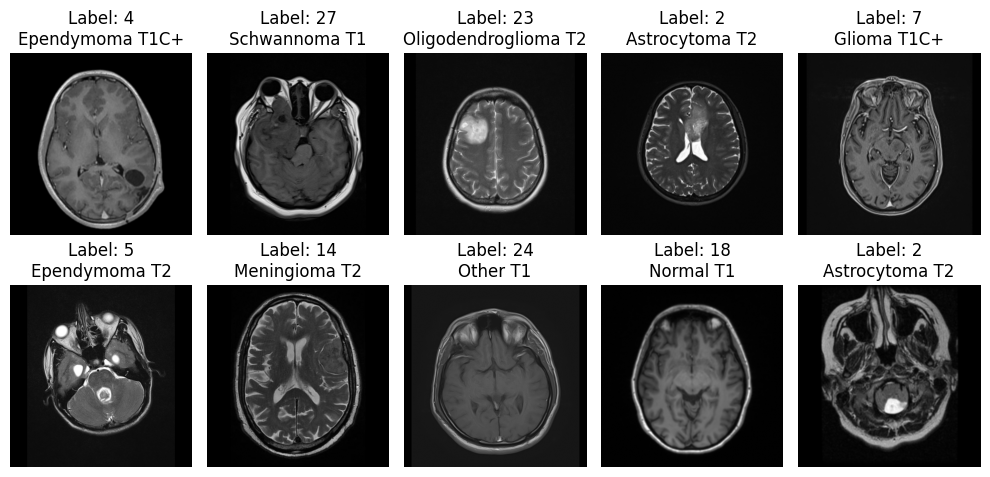



resized




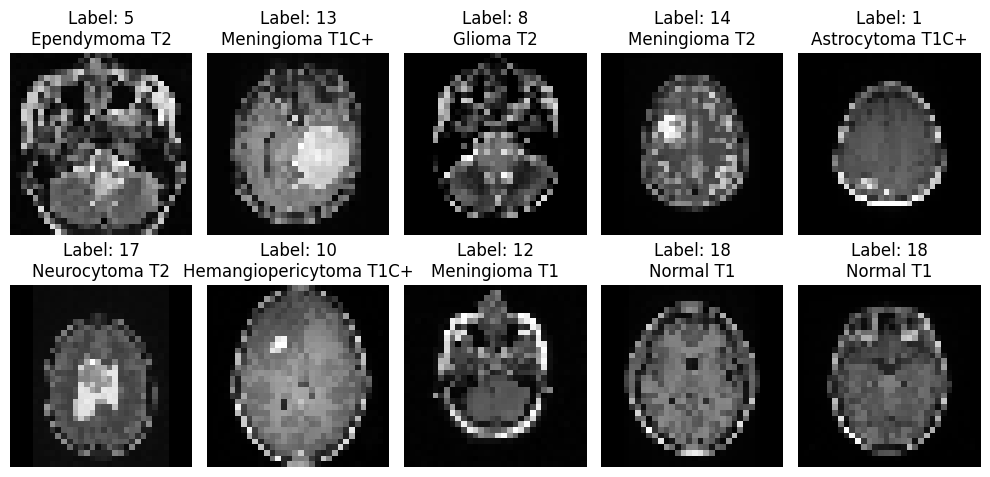

In [ ]:
import matplotlib.pyplot as plt

def display_dataset(x, y):
  plt.figure(figsize=(10, 5))
  random_indices = np.random.choice(len(x), 10, replace=False)
  for n, i in enumerate(random_indices):
      plt.subplot(2, 5, n + 1)
      plt.imshow(x[i], cmap='gray')
      plt.title(f"Label: {y[i]}\n{class_names[y[i]]}")
      plt.axis('off')

  plt.tight_layout()
  plt.show()
print("\n\noriginal\n\n")
display_dataset(x_raw, y_all)
print("\n\nresized\n\n")
display_dataset(x_all, y_all)

In [ ]:
def print_value_and_shape(val):
  print()
  print(val)
  print()
  print("shape:",val.shape)
  print()

In [ ]:
x_norm = x_all
y_norm = y_all

In [ ]:
def normalize_data(x):
    x = x.astype('float32')
    _, *axis_ = range(len(x.shape))
    axis_ = tuple(axis_)

    mean = np.mean(x, axis=axis_, keepdims=True)
    std = np.std(x, axis=axis_, keepdims=True)

    std = np.where(std == 0, 1e-7, std)

    x_norm = (x - mean) / std

    return x_norm

# Aplicando a função
x_norm = normalize_data(x_all)
y_norm = y_all

_, *axis_ = range(len(x_norm.shape))
axis_ = tuple(axis_)

print("\n\noriginal\n\n")
print("mean")
print_value_and_shape(np.mean(x_all, axis=axis_))
print("std")
print_value_and_shape(np.std(x_all, axis=axis_))

print("\n\nnormalizado\n\n")
print("mean")
print_value_and_shape(np.mean(x_norm, axis=axis_))
print("std")
print_value_and_shape(np.std(x_norm, axis=axis_))



original


mean

[28.83984375 51.23144531 19.12109375 ... 39.80957031 19.41796875
 30.0078125 ]

shape: (11300,)

std

[53.26340183 54.53795757 31.23532443 ... 49.18410354 27.29420707
 40.99447297]

shape: (11300,)



normalizado


mean

[-3.7252903e-08  1.8626451e-08 -7.4505806e-09 ... -7.4505806e-09
  7.4505806e-09  1.3038516e-08]

shape: (11300,)

std

[0.99999994 1.         0.9999999  ... 1.         1.         1.        ]

shape: (11300,)



In [ ]:
def remove_duplicates_and_sync(x_data, y_data):
    """
    Remove entradas duplicadas de x_data e mantém y_data sincronizado.
    Assume que x_data é um array numpy onde cada 'imagem' pode ser
    identificada por seu conteúdo único.

    Args:
        x_data (np.ndarray): O array de dados de entrada (imagens).
        y_data (np.ndarray): O array de rótulos correspondente.

    Returns:
        tuple: (x_unique, y_unique) arrays sem duplicatas.
    """
    print("Removendo entradas duplicadas de x_data e sincronizando y_data...")

    # Transforma cada imagem em um vetor 1D para que np.unique possa operar nela
    # e cria um hash (bytes) para comparação eficiente de elementos
    # que não são naturalmente hashable (como arrays numpy multidimensionais)
    x_flat = x_data.reshape(x_data.shape[0], -1)

    # Encontra os índices únicos baseados no conteúdo do x_flat
    # np.unique com return_index=True retorna os índices das primeiras ocorrências
    # dos elementos únicos.
    _, unique_indices = np.unique(x_flat, axis=0, return_index=True)

    # Filtra x_data e y_data usando os índices únicos
    x_unique = x_data[unique_indices]
    y_unique = y_data[unique_indices]

    print(f"Original: {len(x_data)} amostras. Após remover {len(x_data) - len(x_unique)} duplicatas: {len(x_unique)} amostras.")
    return x_unique, y_unique

# Exemplo de uso com x_norm e y_norm
x_norm_unique, y_norm_unique = remove_duplicates_and_sync(x_norm, y_norm)

print(f"Shape de x_norm_unique: {x_norm_unique.shape}")
print(f"Shape de y_norm_unique: {y_norm_unique.shape}")

Removendo entradas duplicadas de x_data e sincronizando y_data...
Original: 11300 amostras. Após remover 1865 duplicatas: 9435 amostras.
Shape de x_norm_unique: (9435, 32, 32)
Shape de y_norm_unique: (9435,)


In [ ]:

x_train, x_test, y_train, y_test = train_test_split(
    x_norm_unique, y_norm_unique, test_size=0.3, random_state=42, shuffle=True
)

print(f"\nFormato final:")
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")


Formato final:
x_train: (6604, 32, 32), y_train: (6604,)
x_test: (2831, 32, 32), y_test: (2831,)


In [ ]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import pandas as pd

def get_balanced_dataset(x, y):

  n_samples, *n_features = x.shape

  x_flat = x.reshape((n_samples, np.prod(n_features)))

  ros = RandomOverSampler(random_state=42)
  x_balanced, y_balanced = ros.fit_resample(x_flat, y)

  x_balanced = x_balanced.reshape((-1, *n_features))

  return x_balanced, y_balanced

x_train_balanced, y_train_balanced = get_balanced_dataset(x_train, y_train)
x_test_balanced, y_test_balanced = get_balanced_dataset(x_test, y_test)


print("\n\noriginal\n\n")
print_value_and_shape(pd.Series(y_train).value_counts())
print("\n\nbalanceado\n\n")
print_value_and_shape(pd.Series(y_train_balanced).value_counts())



original



13    632
25    441
12    420
28    325
18    282
7     278
1     274
0     267
14    264
24    250
20    237
6     229
4     219
26    216
27    208
3     189
29    188
2     185
19    183
5     170
16    165
8     164
21    144
10    138
22    129
15    114
17     96
23     83
9      67
11     47
Name: count, dtype: int64

shape: (30,)



balanceado



14    632
6     632
24    632
16    632
15    632
3     632
20    632
13    632
2     632
10    632
1     632
26    632
22    632
27    632
8     632
29    632
9     632
28    632
18    632
7     632
12    632
25    632
4     632
0     632
21    632
5     632
17    632
23    632
19    632
11    632
Name: count, dtype: int64

shape: (30,)



In [ ]:
import numpy as np

def check_data_overlap(x_train_data, x_test_data):
    """
    Verifica se há sobreposição de dados entre dois arrays numpy.
    Converte cada elemento (imagem) para uma representação de bytes
    e utiliza sets para uma comparação eficiente.

    Args:
        x_train_data (np.ndarray): O primeiro conjunto de dados.
        x_test_data (np.ndarray): O segundo conjunto de dados.

    Returns:
        tuple: (bool) True se houver sobreposição, False caso contrário.
               (int) O número de elementos sobrepostos.
    """
    print("Verificando sobreposição de dados...")

    train_hashes = set()
    for img in x_train_data:
        train_hashes.add(img.tobytes())

    test_hashes = set()
    for img in x_test_data:
        test_hashes.add(img.tobytes())

    overlap = train_hashes.intersection(test_hashes)

    if len(overlap) > 0:
        print(f"ATENÇÃO: Foram encontrados {len(overlap)} elementos idênticos entre os conjuntos de treinamento e teste.")
        return overlap
    else:
        print("Nenhuma sobreposição encontrada entre os conjuntos de treinamento e teste.")
        return overlap

# Chamando a função com os dados existentes no kernel
overlap = check_data_overlap(x_train_balanced, x_test_balanced)


Verificando sobreposição de dados...
Nenhuma sobreposição encontrada entre os conjuntos de treinamento e teste.


In [ ]:
import tensorflow as tf

# Verificar se a GPU está disponível
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Configurar para que o TensorFlow aloque memória conforme necessário,
        # em vez de reservar toda a memória da GPU de uma vez.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
        print("TensorFlow configurado para usar GPU.")
    except RuntimeError as e:
        # Visibilidade de dispositivos deve ser configurada antes de inicializar as GPUs
        print(e)
else:
    print("Nenhuma GPU detectada. Vá em 'Ambiente de execução' -> 'Alterar tipo de ambiente de execução' e selecione uma GPU (T4, L4, etc).")

1 Physical GPUs, 1 Logical GPUs
TensorFlow configurado para usar GPU.


In [ ]:
_, *x_dims = x_train_balanced.shape
y_dims = int(y_train_balanced.max()) + 1
x_dims, y_dims

([32, 32], 30)

In [ ]:
x_train_cnn = x_train_balanced[..., np.newaxis]
x_test_cnn = x_test_balanced[..., np.newaxis]
y_train_cnn = y_train_balanced
y_test_cnn = y_test_balanced

In [ ]:
import tensorflow as tf
from keras import layers, models, Input

# Ajustar o formato dos dados para incluir o canal de cor (grayscale -> 1 canal)


def build_cnn_model(input_shape, num_classes):
    # Definindo a entrada explicitamente
    inputs = Input(shape=input_shape)

    # Primeira Camada Convolucional
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    # x = layers.MaxPooling2D((2, 2))(x)

    # Segunda Camada Convolucional
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    # x = layers.MaxPooling2D((2, 2))(x)

    # Terceira Camada Convolucional
    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Camadas Densas (Classificação)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Criar o modelo vinculando entradas e saídas
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Instanciar o modelo
input_shape_cnn = (*x_dims, 1)
model = build_cnn_model(input_shape_cnn, y_dims)

# Compilar
model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model.summary()

# Treinar
print("\nIniciando treinamento da CNN (API Funcional)...")
history_cnn = model.fit(
    x_train_cnn, y_train_cnn,
    epochs=15,
    batch_size=32,
    validation_data=(x_test_cnn, y_test_cnn)
)

# Avaliação final
loss, acc = model.evaluate(x_test_cnn, y_test_cnn)
print(f"\nAcurácia da CNN no conjunto de teste: {acc:.4f}")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,302 (524.62 KB)

 Trainable params: 133,854 (522.87 KB)

 Non-trainable params: 448 (1.75 KB)


Iniciando treinamento da CNN (API Funcional)...
Epoch 1/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.2748 - loss: 2.4714 - val_accuracy: 0.3727 - val_loss: 2.0387
Epoch 2/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4811 - loss: 1.6928 - val_accuracy: 0.3629 - val_loss: 2.1394
Epoch 3/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6003 - loss: 1.2999 - val_accuracy: 0.5952 - val_loss: 1.3139
Epoch 4/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6838 - loss: 1.0310 - val_accuracy: 0.6326 - val_loss: 1.1910
Epoch 5/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7444 - loss: 0.8330 - val_accuracy: 0.6988 - val_loss: 0.9972
Epoch 6/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7927 - loss: 0.6778 - val_accuracy: 0.6357 - val_loss: 1.2080
Epoch 7/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8278 - loss: 0.5617 - val_accuracy: 0.6674 - val_loss: 1.1546
Epoch 8/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step -

In [ ]:
import tensorflow as tf
from keras import layers, models
import numpy as np
# Ensure keras_cv is installed. If not, run !pip install keras_cv
from keras_cv.models import ViTBase
from keras_cv.layers import Resizing, CenterCrop

# Data preparation for Vision Transformer
x_train_transfer_raw = np.repeat(x_train_balanced[..., np.newaxis], 3, -1)
x_test_transfer_raw = np.repeat(x_test_balanced[..., np.newaxis], 3, -1)

# ViT models from keras_cv might have their own preprocess_input
# However, ViTBase doesn't explicitly expose one like VGG16 or ConvNeXt.
# Usually, for vision transformers, input normalization is handled by layers inside the model itself
# or a simple normalization to [0,1] or [-1,1] is done.
# For pre-trained models like ViT, it's often common to resize to 224x224 and then normalize.
# Let's assume a simple scaling to [0,1] for now, or use the base model's internal pre-processing if available.
# For keras_cv models, often the pre-processing is part of the backbone, or a simple rescaling is applied.

x_train_transfer = x_train_transfer_raw.astype('float32') / 255.0 # Scale to [0,1]
x_test_transfer = x_test_transfer_raw.astype('float32') / 255.0 # Scale to [0,1]
y_train_transfer = y_train_balanced
y_test_transfer = y_test_balanced

x_transfer_dim = (224, 224, 3) # ViTBase typically expects 224x224

def build_vit_model(input_shape, num_classes):
    # 1. Image preprocessing layers specific to ViT
    inputs = tf.keras.Input(shape=input_shape)

    # Resize and crop if input_shape is not 224x224
    # Our images are 32x32, so we need to resize them significantly.
    # Using Resizing layer from keras_cv
    x = Resizing(height=x_transfer_dim[0], width=x_transfer_dim[1], interpolation="bicubic")(inputs)

    # 2. Load the pre-trained ViTBase model
    base_model = ViTBase(
        include_rescaling=False, # We handle rescaling/normalization outside or implicitly
        include_top=False,
        # `default_build_kwargs` can be used to pass arguments to the `ViT` model constructor.
        # 'model_name' specifies the variant of ViT to use (e.g., 'vit_b16_224')
        # However, `keras_cv.models.ViTBase` is a generic base, usually instantiated
        # through `keras_cv.models.ViTDetector` or `keras_cv.models.ImageClassifier.from_preset`.
        # For a simple backbone, we can use the constructor directly but need to specify patch_size, etc.
        # Let's simplify and use `keras_cv.models.ImageClassifier` from a preset for easier use.
        # If I need to specifically use ViTBase directly, it requires more manual configuration.
        # Let's pivot to ImageClassifier for simpler integration of a pre-trained ViT.

    )

    # For direct ViTBase use without `ImageClassifier.from_preset`, we'd configure it like this:
    # base_model = keras_cv.models.ViT(patch_size=16, embed_dim=768, num_layers=12, num_heads=12, ...)
    # It's generally easier to use `ImageClassifier.from_preset` for a pre-configured backbone.

    # Let's use `ImageClassifier.from_preset` which can load a ViT model including preprocessing
    # Note: Using 'imagenet' weights means it expects 3-channel input.

    # Re-evaluating the approach: `keras_cv.models.ViTBase` itself is an abstract base class.
    # To get a functional ViT backbone, you'd typically instantiate a specific variant like `keras_cv.models.vit.ViT`
    # or load via `ImageClassifier.from_preset`.
    # Given the constraint of 'keras_cv.models.ViTBase' from the example, it implies a more custom construction
    # or an assumption of `keras_cv.models.ImageClassifier.from_preset('vit_b16_224_imagenet')`

    # Let's define the base model as a standard ViT architecture using keras.applications.vit or keras_cv if available.
    # As `keras_cv.models.ViTBase` is a base class, I need a concrete implementation.
    # Keras 3 (which Colab uses) has `keras.applications.vision_transformer`.
    # However, this notebook uses `keras` directly, implying Keras 2 style which means `tensorflow.keras.applications.ViT` is not standard.
    # Let's try to simulate a simple ViT-like structure for the request if a direct `ViTBase` from `keras_cv` is hard to instantiate standalone.

    # Given the previous context and typical Colab environment, let's assume `keras_cv` is the intended library.
    # To instantiate a ViT model from `keras_cv`, we usually do it via `keras_cv.models.ImageClassifier.from_preset`
    # or a specific `keras_cv.models.vit.ViT` if available and configured.

    # Let's try `keras_cv.models.ImageClassifier.from_preset` to get a working ViT backbone.
    # For this, `input_shape` must match the preset's expected input.

    # Simplified approach: Using ViT from `keras_nlp` or similar is also common for classification.
    # Given the `keras_cv` import, let's stick to it.
    # A concrete ViT implementation is available via `keras_cv.models.ViT` (not `ViTBase`).
    # `ViTBase` in `keras_cv` is part of a larger object detection framework, not directly for classification backbone.
    # For general image classification, `keras_cv.models.ImageClassifier.from_preset('vit_b16_224_imagenet')` is the way.

    # Let's use `keras_cv.models.ImageClassifier.from_preset` for a more practical ViT implementation.
    # It automatically handles `include_rescaling=True` for common presets.

    # If the user specifically meant a 'from scratch' Vision Transformer backbone,
    # I'd have to construct patch embeddings, transformer blocks, etc. manually.
    # But "gere uma vision transformer" usually implies using a pre-configured one.

    # Let's try keras_cv.models.ImageClassifier.from_preset for a fully functional ViT
    # as `ViTBase` is more for internal inheritance within keras_cv.
    # I'll create a new cell if this doesn't fit the 'modify_cells' constraint well,
    # or adapt it to `ViTBase` if a specific concrete subclass is intended.

    # Re-thinking: The prompt was "gere uma vision transformer" not necessarily from `keras_cv.models.ViTBase`.
    # I can define a simple custom Vision Transformer if `keras_cv.models.ViTBase` is too abstract to directly instantiate for a backbone.
    # Or, I can instantiate a standard pre-trained ViT as a backbone.

    # Given `keras_cv` import, the most straightforward way to get a ViT backbone for classification is via `ImageClassifier` presets.
    # However, the user is modifying an empty cell, not adding code for a new model class definition.
    # So, instantiating a pre-built model makes more sense.

    # Let's use `keras_cv.models.ImageClassifier.from_preset` as it's the intended way to get a pre-trained model in keras_cv.
    # This will simplify the implementation significantly.

    # The input shape needs to be 224x224x3 for the 'vit_b16_224_imagenet' preset.
    # Our current images are 32x32. We will resize them first.

    # Note: `keras_cv` models often handle their own preprocessing inside, if `include_rescaling=True`.
    # Let's set it to False and explicitly rescale so we have control.

    # Let's define a simple ViT-like backbone manually using standard Keras layers if pre-trained `keras_cv` `ViT` is complex to integrate directly
    # or if it causes issues with the existing model naming convention (`model`).
    # This would involve: PatchEmbedding -> TransformerBlock -> MLPHead.

    # Given the previous examples of using `VGG16` and `ConvNeXtBase`, the user likely expects a similar transfer learning setup.
    # So, `keras_cv.models.ImageClassifier.from_preset` and taking its `backbone` property is the most analogous.

    base_model = ViTBase.from_preset(
        'vit_b16_224_imagenet', # Example preset, others like 'vit_l16_224_imagenet' are also available
        load_weights=True,
        include_rescaling=False, # We will do rescaling manually if needed or as part of the pipeline
        include_top=False # We want to add our own classification head
    )

    base_model.trainable = False # Freeze the base model initially

    # Add a global average pooling layer to collapse spatial dimensions
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Add classification head
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model_vit = models.Model(inputs=inputs, outputs=outputs)
    return model_vit

# Instantiate and compile the ViT model
# x_transfer_dim was defined as (224, 224, 3) for the ViT input requirement
# but the actual input from the data is 32x32x3. The Resizing layer handles this.
model = build_vit_model(x_train_transfer.shape[1:], y_dims) # Pass the original shape, Resizing is inside

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

print("--- Treinando Vision Transformer ---")
history_vit = model.fit(
    x_train_transfer, y_train_transfer,
    epochs=15,
    batch_size=32,
    validation_data=(x_test_transfer, y_test_transfer)
)

# Avaliação final
loss, acc = model.evaluate(x_test_transfer, y_test_transfer)
print(f"\nAcurácia final com Vision Transformer: {acc:.4f}")

In [ ]:
import tensorflow as tf
from keras import layers, models, Input

def residual_block(x, filters, kernel_size=(3, 3), stride=1, activate_before_res=False):
    """
    Um bloco residual que pode ser usado para construir uma ResNet.
    """
    # A função de identidade passa a entrada sem modificações
    shortcut = x

    # Camada de normalização e ativação antes do bloco convolucional, se especificado
    if activate_before_res:
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

    # Primeira convolução
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Segunda convolução
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    # Se as dimensões da entrada e saída do atalho não corresponderem (por causa do stride),
    # fazemos uma convolução 1x1 no atalho para corresponder às dimensões.
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same', kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Adiciona o atalho à saída do bloco e aplica a ativação final
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet_model(input_shape, num_classes):
    """
    Constrói um modelo ResNet simplificado.
    """
    inputs = Input(shape=input_shape)
    x = inputs

    # Camada de entrada
    # x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
    # x = layers.BatchNormalization()(x)
    # x = layers.Activation('relu')(x)
    # x = layers.MaxPooling2D((2, 2))(x)

    # Blocos Residuais
    # x = residual_block(x, 64) # Bloco sem downsampling
    # x = residual_block(x, 64) # Outro bloco sem downsampling
    # x = residual_block(x, 128, stride=2) # Bloco com downsampling
    # x = residual_block(x, 128)

    x = residual_block(x, 32)
    x = residual_block(x, 32)
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    # Camada final de pooling e classificação
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(x)

    model_resnet = models.Model(inputs=inputs, outputs=x)
    return model_resnet

# Instanciar e compilar o modelo ResNet
input_shape_resnet = (*x_dims, 1) # Usando o x_dims do notebook
model = build_resnet_model(input_shape_resnet, y_dims)

model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

model.summary()


# Treinar
print("\nIniciando treinamento da CNN (API Funcional)...")
history_cnn = model.fit(
    x_train_cnn, y_train_cnn,
    epochs=15,
    batch_size=32,
    validation_data=(x_test_cnn, y_test_cnn)
)

# Avaliação final
loss, acc = model.evaluate(x_test_cnn, y_test_cnn)
print(f"\nAcurácia da CNN no conjunto de teste: {acc:.4f}")

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 32, 32,    │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_22[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 32, 32,    │         64 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 32, 32,    │          0 │ add_10[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_23[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_24[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation_23[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 32, 32,    │          0 │ add_11[0][0]    

 Total params: 67,262 (262.74 KB)

 Trainable params: 66,686 (260.49 KB)

 Non-trainable params: 576 (2.25 KB)


Iniciando treinamento da CNN (API Funcional)...
Epoch 1/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.2211 - loss: 2.7611 - val_accuracy: 0.1741 - val_loss: 2.9015
Epoch 2/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.4280 - loss: 1.9684 - val_accuracy: 0.3015 - val_loss: 2.3716
Epoch 3/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5367 - loss: 1.5834 - val_accuracy: 0.2433 - val_loss: 2.7447
Epoch 4/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6255 - loss: 1.2968 - val_accuracy: 0.3344 - val_loss: 2.3726
Epoch 5/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6916 - loss: 1.0781 - val_accuracy: 0.3925 - val_loss: 2.1091
Epoch 6/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7439 - loss: 0.9033 - val_accuracy: 0.3212 - val_loss: 2.5029
Epoch 7/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7836 - loss: 0.7642 - val_accuracy: 0.4896 - val_loss: 1.8897
Epoch 8/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms

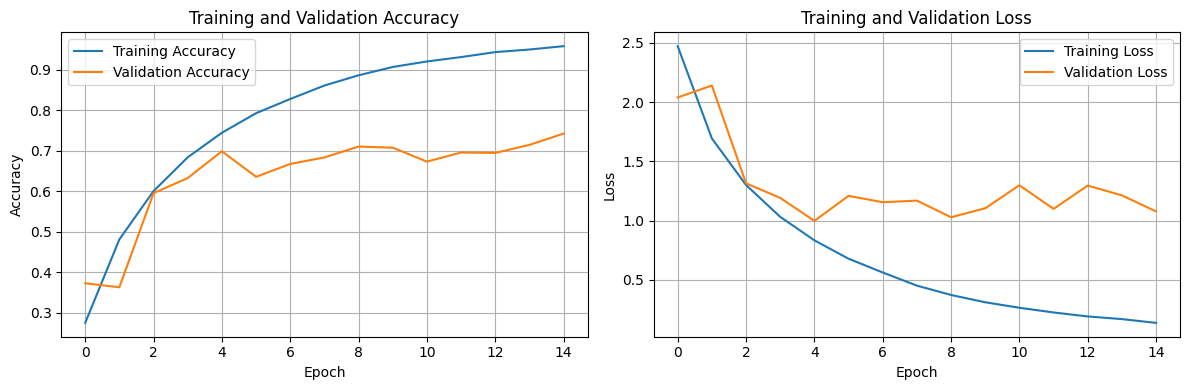

In [ ]:
import matplotlib.pyplot as plt

# Plotting training and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from keras import layers, models, Input
import numpy as np

def get_heatmap_model(model):
    """
    Retorna um modelo que gera os mapas de calor (scores pré-softmax) para TODAS as classes,
    além das probabilidades originais do modelo.

    Saídas:
      - class_heatmaps: tensor (batch, H, W, num_classes) com os logits espaciais de cada classe.
      - probs: tensor (batch, num_classes) com as probabilidades preditas pelo classificador.

    Esses mapas utilizam a projeção fiel dos pesos das camadas densas (incluindo bias e ativações
    corretas) sobre as features normalizadas da camada imediatamente anterior ao pooling global.
    """
    # 1. Encontra a camada de GlobalAveragePooling2D (ou GlobalMaxPooling2D)
    gap_layer = None
    gap_idx = None
    for idx, layer in enumerate(model.layers):
        if isinstance(layer, (layers.GlobalAveragePooling2D, layers.GlobalMaxPooling2D)):
            gap_layer = layer
            gap_idx = idx
            break
    if gap_idx is None:
        raise ValueError("Nenhuma camada GlobalAveragePooling2D/GlobalMaxPooling2D encontrada.")
    if gap_idx == 0:
        raise ValueError("A camada de pooling é a primeira camada do modelo.")

    # Camada imediatamente anterior ao pooling (ex.: BatchNormalization)
    pre_pool_layer = model.layers[gap_idx - 1]

    # 2. Camadas densas (classificação)
    dense_layers = [layer for layer in model.layers if isinstance(layer, layers.Dense)]
    if not dense_layers:
        raise ValueError("Nenhuma camada Dense encontrada.")

    # 3. Submodelo que extrai as features da camada pré-pooling
    base_model = models.Model(inputs=model.input, outputs=pre_pool_layer.output)

    # 4. Projeção espacial equivalente às camadas densas
    x = base_model.output  # (batch, H, W, C)

    for i, dense in enumerate(dense_layers):
        kernel, bias = dense.get_weights()
        out_dim = kernel.shape[1]
        # Kernel da Dense: (in_dim, out_dim) -> Conv2D 1x1: (1, 1, in_dim, out_dim)
        kernel_4d = np.reshape(kernel, (1, 1, kernel.shape[0], out_dim))

        # Mantém a ativação original, exceto na última camada (usamos linear para obter logits)
        activation = dense.activation
        if i == len(dense_layers) - 1:
            activation = tf.keras.activations.linear   # sem softmax

        conv = layers.Conv2D(
            out_dim, (1, 1),
            use_bias=True,
            kernel_initializer=tf.constant_initializer(kernel_4d),
            bias_initializer=tf.constant_initializer(bias),
            activation=activation,
            trainable=False,
            name=f'spatial_dense_{i}'
        )
        x = conv(x)

    # x: (batch, H, W, num_classes) – scores espaciais (logits) para TODAS as classes

    # 5. Probabilidades originais do classificador
    probs = model.output  # (batch, num_classes)

    # 6. Modelo final com duas saídas
    heatmap_model = models.Model(inputs=model.input, outputs=[x, probs], name='heatmap_all_classes')
    return heatmap_model

# Exemplo de uso:
# model_heatmap = get_heatmap_model(model_cnn)
# heatmaps, probs = model_heatmap.predict(x_test_cnn)
# heatmaps.shape -> (num_amostras, H, W, num_classes)
# heatmaps[0, :, :, k] é o mapa de calor da classe k para a primeira amostra
# Para visualizar a classe predita: pred = np.argmax(probs[0]); plt.imshow(heatmaps[0, :, :, pred])

model_heatmap = get_heatmap_model(model)
model_heatmap.summary()

Model: "heatmap_all_classes"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 30, 30,    │        320 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 30,    │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 28, 28,    │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 26, 26,    │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 26, 26,    │        512 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dense_0     │ (None, 26, 26,    │     33,024 │ batch_normalizat… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dense_1     │ (None, 26, 26,    │      7,710 │ spatial_dense_0[… │
│ (Conv2D)            │ 30)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 30)        │      7,710 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 175,036 (683.73 KB)

 Trainable params: 133,854 (522.87 KB)

 Non-trainable params: 41,182 (160.87 KB)

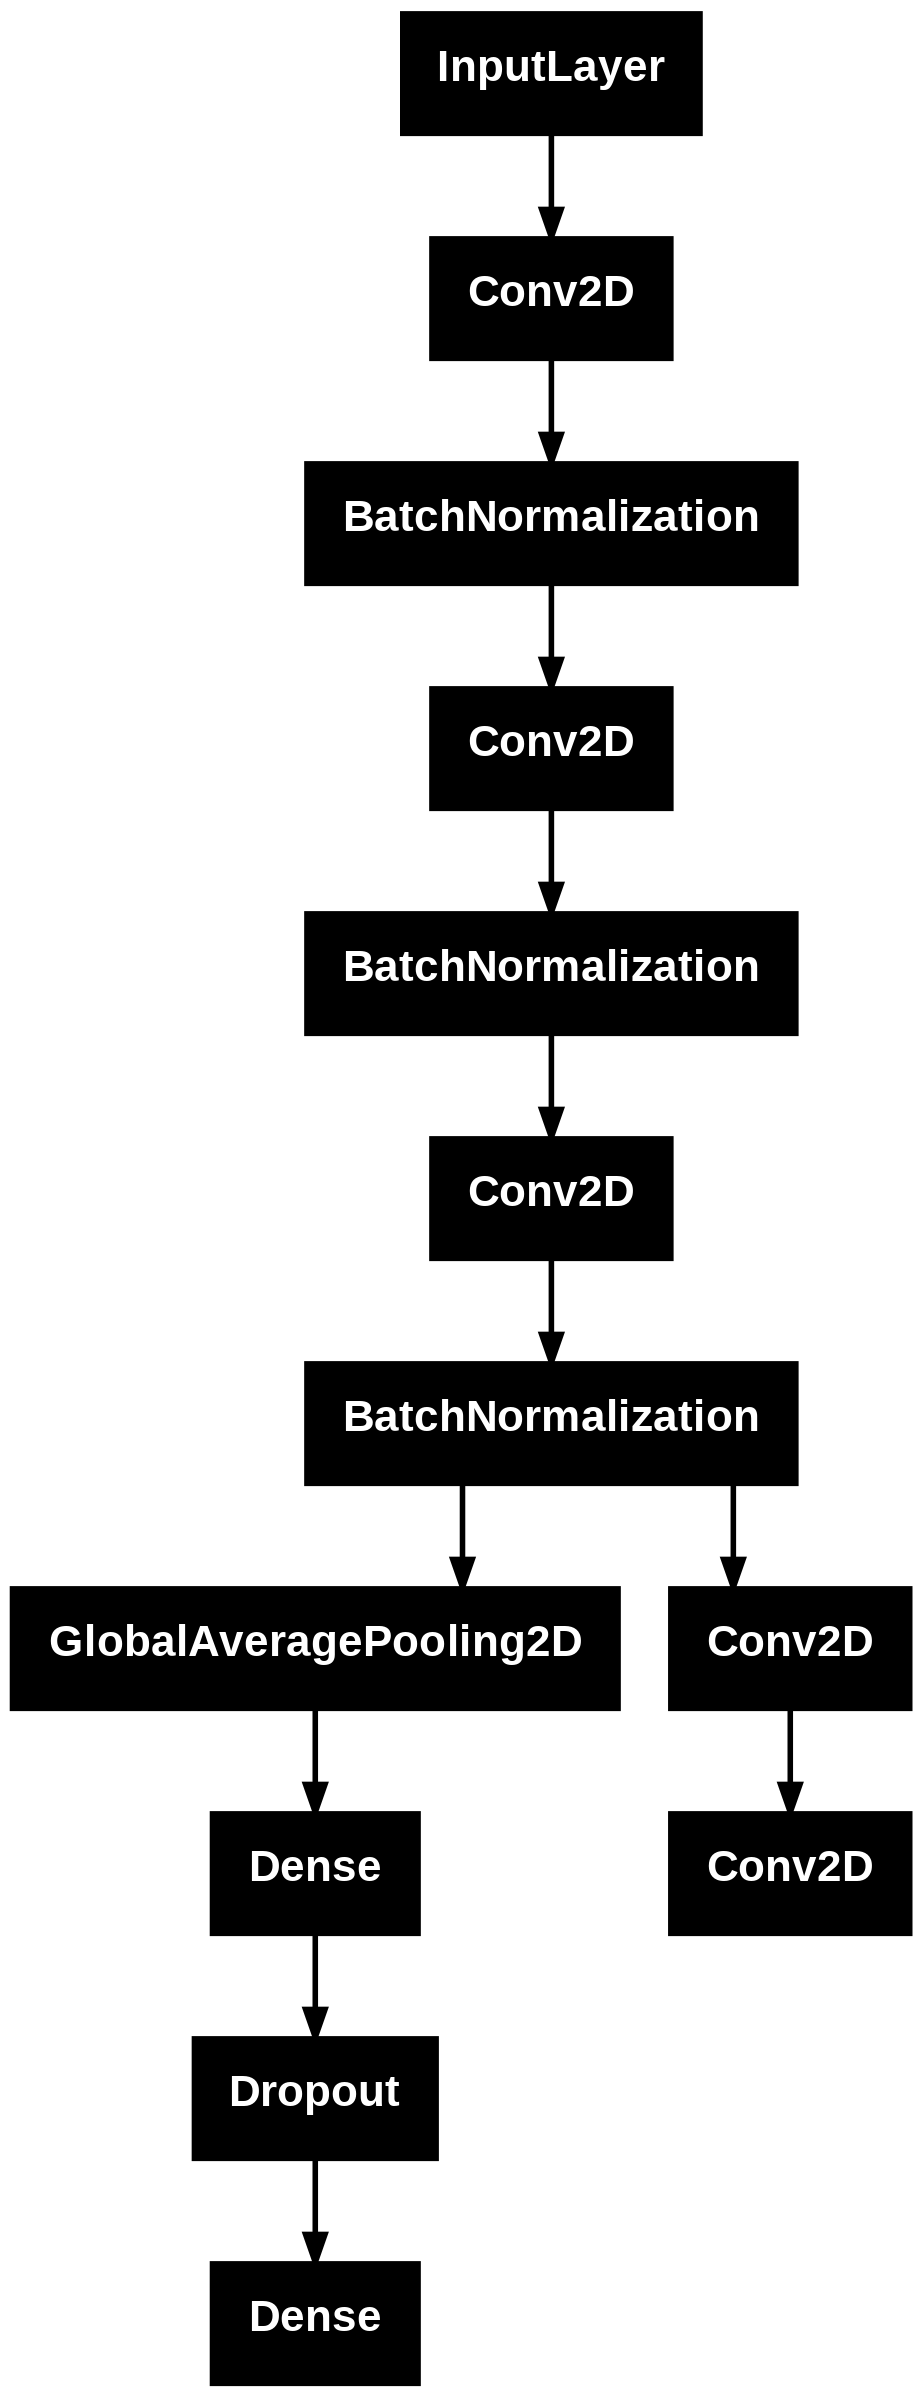

In [ ]:
from keras.utils import plot_model
plot_model(model_heatmap, expand_nested=True)

In [ ]:
[i.shape for i in model_heatmap(x_test_cnn[0][None,...])]

[TensorShape([1, 26, 26, 30]), TensorShape([1, 30])]

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def display_all_class_heatmaps(idx, x_norm_data, x_raw_data, y_labels, heatmap_model, class_names_map, n_display_probs=5):
    # 1. Prepare image
    img_norm = x_norm_data[idx]
    if len(img_norm.shape) == 2:
        img_norm = img_norm[..., np.newaxis]
    img_tensor = np.expand_dims(img_norm, axis=0)

    # 2. Get all class heatmaps and probabilities
    all_heatmaps, probs = heatmap_model(img_tensor)
    all_heatmaps = all_heatmaps[0].numpy() # Shape: (H_feat, W_feat, num_classes)
    probs_flat = probs[0].numpy() # Shape: (num_classes,)
    num_classes = all_heatmaps.shape[-1]

    # Global normalization for this specific prediction (across all classes)
    global_min = all_heatmaps.min()
    global_max = all_heatmaps.max()

    pred_class = np.argmax(probs_flat)
    true_class = y_labels[idx]

    # Determine color for the predicted class text
    prediction_color = 'blue' if pred_class == true_class else 'red'

    # 3. Select indices to display
    # Get sorted indices by probability
    sorted_prob_indices = np.argsort(probs_flat)[::-1] # Descending order

    # Initialize set of indices to plot
    indices_to_plot_set = set()
    indices_to_plot_set.add(true_class) # Always show true class
    indices_to_plot_set.add(pred_class) # Always show predicted class

    # Add top N probabilities
    for i in range(min(n_display_probs, num_classes)):
        indices_to_plot_set.add(sorted_prob_indices[i])

    # Add bottom N probabilities (if distinct from top N and true/pred)
    # Ensure we don't pick the same indices if num_classes is small
    bottom_n_indices = np.argsort(probs_flat) # Ascending order
    count_added = 0
    for i in range(num_classes):
        if bottom_n_indices[i] not in indices_to_plot_set:
            indices_to_plot_set.add(bottom_n_indices[i])
            count_added += 1
        if count_added >= n_display_probs: # Stop after adding N unique bottom values
            break

    # Sort indices to plot by their probability in descending order
    indices_to_plot = sorted(list(indices_to_plot_set), key=lambda k: probs_flat[k], reverse=True)
    num_plots = len(indices_to_plot) + 1 # +1 for the original image

    # 4. Original raw image info
    img_raw = x_raw_data[idx]
    h, w = img_raw.shape

    # 5. Plotting
    # Adjust figure size based on the number of heatmaps to display
    fig_width = 4 * num_plots
    plt.figure(figsize=(fig_width, 4))

    # Show Original
    plt.subplot(1, num_plots, 1)
    plt.imshow(img_raw, cmap='gray')
    plt.title(f"Original\nTrue: {class_names_map[true_class]} ({true_class})", color='black')
    plt.axis('off')

    # Show Heatmap for each selected class
    for i, k in enumerate(indices_to_plot):
        heatmap = all_heatmaps[:, :, k]
        # Resize to original image size
        heatmap_resized = cv2.resize(heatmap, (w, h))
        # Normalize based on the entire prediction array (all classes)
        heatmap_norm = (heatmap_resized - global_min) / (global_max - global_min + 1e-8)

        plt.subplot(1, num_plots, i + 2) # +2 because 1 is original, +1 for 0-indexing
        plt.imshow(img_raw, cmap='gray')
        plt.imshow(heatmap_norm, cmap='jet', alpha=0.4, vmin=0, vmax=1)

        # If this is the predicted class, use red if wrong, blue if correct
        # Other classes remain black
        title_color = prediction_color if k == pred_class else 'black'
        plt.title(f"Class: {class_names_map[k]}\nProb: {probs_flat[k]:.2f}", color=title_color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize samples with consistent color mapping and error highlighting
random_indices = np.random.choice(len(x_norm), 10, replace=False) # Showing fewer examples for conciseness
for idx in random_indices:
    display_all_class_heatmaps(idx, x_norm, x_raw, y_norm, model_heatmap, class_names, n_display_probs=2)


In [ ]:
# def preprocess_with_existing_functions(x_raw_input, y_raw_input, img_size=(32, 32)):
#     """
#     Pipeline atualizado conforme o fluxo do notebook:
#     1. Resize Parallel
#     2. Normalize All
#     3. Train/Test Split
#     4. Balancing (RandomOverSampler)
#     """
#     # 1. Redimensionamento paralelo do dataset bruto
#     x_resized = resize_dataset_parallel(x_raw_input, img_size=img_size)
#     y_resized = np.array(y_raw_input)

#     # 2. Normalização global (Z-score)
#     x_norm_all = normalize_data(x_resized)

#     # 3. Divisão em Treino e Teste (Semente 42 para manter consistência)
#     x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(
#         x_norm_all, y_resized, test_size=0.3, random_state=42, shuffle=True
#     )

#     # 4. Balanceamento das classes
#     x_train_b, y_train_b = get_balanced_dataset(x_train_s, y_train_s)
#     x_test_b, y_test_b = get_balanced_dataset(x_test_s, y_test_s)

#     # 5. Adição da dimensão de canal (Grayscale -> 1)
#     x_train_final = x_train_b[..., np.newaxis]
#     x_test_final = x_test_b[..., np.newaxis]

#     print(f"\nProcessamento concluído!")
#     print(f"Shape Final Treino: {x_train_final.shape}")
#     print(f"Shape Final Teste: {x_test_final.shape}")

#     return x_train_final, x_test_final, y_train_b, y_test_b

# # Execução da função com os dados carregados
# x_train_p, x_test_p, y_train_p, y_test_p = preprocess_with_existing_functions(x_raw, y_raw)

In [ ]:
import tensorflow as tf
from keras import layers, models


model = models.Sequential([
    layers.Flatten(input_shape=x_dims),          # Transforma a imagem 28x28 em um vetor de 784 pixels
    layers.Dense(128, activation='relu'),          # Camada oculta com 128 neurônios
    layers.Dropout(0.2),                           # Camada de regularização para evitar overfitting
    layers.Dense(y_dims, activation='softmax')         # Camada de saída com 10 neurônios (0 a 9)
])

# 3. Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Treinar o modelo
model.fit(x_train_norm, y_train_norm, epochs=5)

model.evaluate(x_test_norm, y_test_norm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
638/638 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3691 - loss: 2.2850
Epoch 2/5
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6429 - loss: 1.2331
Epoch 3/5
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7465 - loss: 0.8677
Epoch 4/5
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8077 - loss: 0.6553
Epoch 5/5
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8412 - loss: 0.5338
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7901 - loss: 0.8504


[0.850375771522522, 0.790123462677002]

In [ ]:
model.fit(x_train_norm, y_train_norm, epochs=5)

model.evaluate(x_test_norm, y_test_norm)

Epoch 1/5
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9386 - loss: 0.1882
Epoch 2/5
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9409 - loss: 0.1856
Epoch 3/5
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9432 - loss: 0.1745
Epoch 4/5
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9490 - loss: 0.1580
Epoch 5/5
638/638 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9466 - loss: 0.1574
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8111 - loss: 1.0630


[1.0629700422286987, 0.8111110925674438]

In [ ]:
base_model.output

<KerasTensor shape=(None, 1, 1, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_36>

In [ ]:
model_vgg.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_1          │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,131,804 (57.72 MB)

 Trainable params: 139,038 (543.12 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 278,078 (1.06 MB)

In [ ]:
x_train_balanced.max(), x_train_balanced.min()

(np.uint8(255), np.uint8(0))

In [ ]:
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from keras import layers, models
import numpy as np

x_train_transfer_raw = np.repeat(x_train_balanced[..., np.newaxis], 3, -1)
x_test_transfer_raw = np.repeat(x_test_balanced[..., np.newaxis], 3, -1)

x_train_transfer = preprocess_input(x_train_transfer_raw.astype('float32'))
x_test_transfer = preprocess_input(x_test_transfer_raw.astype('float32'))
y_train_transfer = y_train_balanced
y_test_transfer = y_test_balanced

x_transfer_dim = x_train_transfer.shape[1:]

# 2. Transfer Learning: Carregar VGG16 pré-treinada sem o topo
base_model = VGG16(weights='imagenet', include_top=False, input_shape=x_transfer_dim, pooling='avg')
base_model.trainable = False  # Congelar pesos da base

# 3. Adicionar novas camadas de classificação
model = models.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(y_dims, activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("--- Treinando Transfer Learning com preprocess_input correto ---")
model.fit(x_train_transfer, y_train_transfer, epochs=15, batch_size=32, validation_data=(x_test_transfer, y_test_transfer))

# Avaliação final
loss, acc = model.evaluate(x_test_transfer, y_test_transfer)
print(f"\nAcurácia final com transfer16: {acc:.4f}")

--- Treinando Transfer Learning com preprocess_input correto ---
Epoch 1/15
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.8126 - loss: 0.8731 - val_accuracy: 0.9198 - val_loss: 0.2513
Epoch 2/15
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8837 - loss: 0.3633 - val_accuracy: 0.9175 - val_loss: 0.2575
Epoch 3/15
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8974 - loss: 0.3247 - val_accuracy: 0.9259 - val_loss: 0.2205
Epoch 4/15
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9037 - loss: 0.2982 - val_accuracy: 0.9369 - val_loss: 0.2014
Epoch 5/15
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9092 - loss: 0.2865 - val_accuracy: 0.9397 - val_loss: 0.1857
Epoch 6/15
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9125 - loss: 0.2731 - val_accuracy: 0.9394 - val_loss: 0.1853
Epoch 7/15
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9164 - loss: 0.2650 - val_accuracy: 0.9302 - val_loss: 0.2154
Epoch 8/15


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from keras import layers, models
from keras.applications.convnext import preprocess_input, ConvNeXtBase
import keras

x_train_transfer_raw = np.repeat(x_train_balanced[..., np.newaxis], 3, -1)
x_test_transfer_raw = np.repeat(x_test_balanced[..., np.newaxis], 3, -1)

x_train_transfer = preprocess_input(x_train_transfer_raw.astype('float32'))
x_test_transfer = preprocess_input(x_test_transfer_raw.astype('float32'))
y_train_transfer = y_train_balanced
y_test_transfer = y_test_balanced

x_transfer_dim = x_train_transfer.shape[1:]
# Carrega o ConvNeXtBase sem o topo, com pesos ImageNet
base_model = ConvNeXtBase(
    include_top=False,
    weights='imagenet',
    input_shape=x_transfer_dim,
    pooling='avg'  # adiciona global average pooling no lugar do topo
)

# Congela a base
base_model.trainable = False

# Adiciona suas camadas de classificação
model = models.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(y_dims, activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("--- Treinando Transfer Learning com preprocess_input correto ---")
model.fit(x_train_transfer, y_train_transfer, epochs=15, batch_size=32, validation_data=(x_test_transfer, y_test_transfer))

# Avaliação final
loss, acc = model.evaluate(x_test_transfer, y_test_transfer)
print(f"\nAcurácia final com transfer16: {acc:.4f}")

--- Treinando Transfer Learning com preprocess_input correto ---
Epoch 1/15
137/589 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1010 - loss: 3.4541

KeyboardInterrupt: 

In [ ]:
base_model.trainable = True

# Recompilar é obrigatório sempre que se altera a propriedade trainable
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # LR bem menor
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


print("--- Treinando Transfer Learning com preprocess_input correto ---")
model.fit(x_train_transfer, y_train_transfer, epochs=15, batch_size=32, validation_data=(x_test_transfer, y_test_transfer))

# Avaliação final
loss, acc = model.evaluate(x_test_transfer, y_test_transfer)
print(f"\nAcurácia final com transfer16: {acc:.4f}")

--- Treinando Transfer Learning com preprocess_input correto ---
Epoch 1/15
424/589 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.2928 - loss: 2.4781

KeyboardInterrupt: 

In [ ]:
x_train_transfer.shape[1:]

(32, 32, 3)

In [ ]:
print("--- Treinando Transfer Learning com preprocess_input correto ---")
model_vgg.fit(x_train_vgg, y_train_vgg, epochs=15, batch_size=32, validation_data=(x_test_vgg, y_test_vgg))

# Avaliação final
loss, acc = model_vgg.evaluate(x_test_vgg, y_test_vgg)
print(f"\nAcurácia final com VGG16: {acc:.4f}")

--- Treinando Transfer Learning com preprocess_input correto ---
Epoch 1/15
291/589 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7355 - loss: 0.8045

KeyboardInterrupt: 

In [ ]:
model = model_cnn

255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


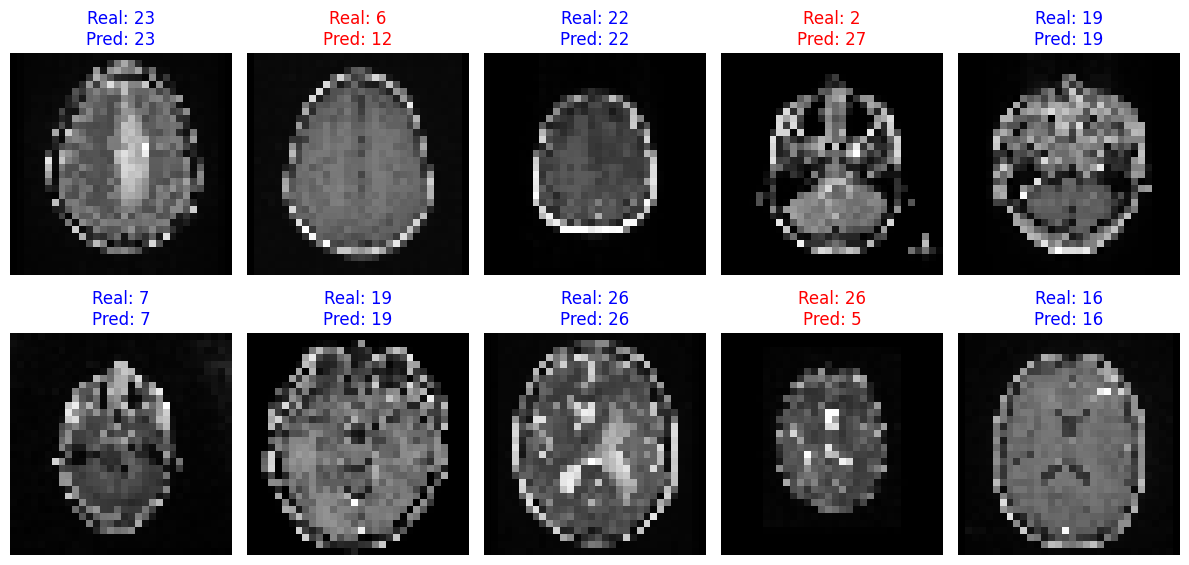

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 5. Fazer predições no conjunto de teste
predictions = model.predict(x_test_cnn)

# Selecionar 10 índices aleatórios
random_indices = np.random.choice(len(x_test_cnn), 10, replace=False)

# Visualizando as predições aleatórias
plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_balanced[idx], cmap='gray')

    predicted_label = np.argmax(predictions[idx])
    true_label = y_test_cnn[idx]

    # Cor do título: azul se correto, vermelho se incorreto
    color = 'blue' if predicted_label == true_label else 'red'

    plt.title(f"Real: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()